## SciPy Interpolation

What is Interpolation?

Interpolation is a method for generating points between given points.

For example: for points 1 and 2, we may interpolate and find points 1.33 and 1.66.

Interpolation has many usage, in Machine Learning we often deal with missing data in a dataset, interpolation is often used to substitute those values.

This method of filling values is called imputation.

Apart from imputation, interpolation is often used where we need to smooth the discrete points in a dataset


## How to Implement it in SciPy?

scipy provides us with a module called scipy.interpolate which has many functions to deal with interpolation:


## 1D Interpolation

the function interp1d() is used to interpolate a distribution with 1 variable 

it takes x and y points and returns a callable function that can be called with new x and return corresponding y

 interp1d(x, y) creates a function that estimates (interpolates) y-values for new x-values based on known data points.

In [ ]:
from scipy.interpolate import interp1d
import numpy as np

xs=np.arange(10)
ys=2*xs+1

interp_func=interp1d(xs,ys)
## creates a function f(x)=2*x + 1
## SciPy connects every pair of neighboring points with a straight line.
## For points: (2,5) ----- (3,7) , the value at x=2.5 is estimated from the straight line between them.
## This works well for linear data but is less accurate for curved data.
newarr=interp_func(np.arange(2.1,3,0.1))
newarr

array([5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4, 6.6, 6.8])

In [20]:
x=np.linspace(0,10,20)
y=x**2

interp_func=interp1d(x,y)

interp_func(np.arange(10))

array([ 0.        ,  1.02493075,  4.04432133,  9.05817175, 16.06648199,
       25.06925208, 36.06648199, 49.05817175, 64.04432133, 81.02493075])

Notice these are close to:  [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]  but not exactly equal.

Why?

Because interp1d uses linear interpolation by default (kind='linear').

It connects neighboring sample points with straight lines and estimates values along those lines.

So the parabola is approximated by many tiny straight-line segments.

 
Higher-order interpolation

If you want a smoother approximation for curved data:

interp_func = interp1d(x, y, kind='cubic')

kind='cubic' uses cubic splines instead of straight lines and usually matches smooth functions much better.

Common options:

kind='nearest'
kind='linear'   # default
kind='quadratic'
kind='cubic'

In [21]:
x=np.linspace(0,10,20)
y=x**2

interp_func=interp1d(x,y,kind='quadratic')

interp_func(np.arange(10))

array([ 0.,  1.,  4.,  9., 16., 25., 36., 49., 64., 81.])

## Spline Interpolation

In 1D interpolation the points are fitted for a single curve whereas in Spline interpolation the points are fitted against a piecewise function defined with polynomials called splines.

What's the difference from interp1d?

Linear interpolation (interp1d default)

In your previous example:

interp_func = interp1d(xs, ys)

SciPy connects every pair of neighboring points with a straight line.

For points:

(2,5) ----- (3,7)

the value at x=2.5 is estimated from the straight line between them.

Graphically:

*
 \
  \
   *

This works well for linear data but is less accurate for curved data.

Spline interpolation

With:

from scipy.interpolate import UnivariateSpline

SciPy fits a collection of low-degree polynomials that join smoothly together.

Instead of one straight segment:

you get a smooth curve:

*
 )
  )
   *

This collection of smoothly connected polynomial pieces is called a spline.


What does "piecewise function" mean?

A piecewise function uses different equations in different ranges.

For example:

0 ≤ x < 1    -> first polynomial
1 ≤ x < 2    -> second polynomial
2 ≤ x < 3    -> third polynomial

Each polynomial is chosen so that:

the curve passes through (or near) the data points
the joins are smooth
slopes match at boundaries

NOTE: Common parameters: 
UnivariateSpline(x, y, s=0)             (Exact interpolation)

s=0 forces the spline to pass through every point.

Smoothing spline
UnivariateSpline(x, y, s=10)

Allows some deviation from points to reduce noise.

Useful when measurements contain errors.

In [31]:
from scipy.interpolate import UnivariateSpline
import numpy as np

x=np.arange(10)
y=x**2 + np.sin(x) + 1


interp_func=UnivariateSpline(x,y)
newarr=interp_func(np.arange(2.1,3,0.1))

print(newarr)

[5.62826474 6.03987348 6.47131994 6.92265019 7.3939103  7.88514634
 8.39640439 8.92773053 9.47917082]


## Radial Basis Function (RBF) interpolation

RBF interpolation is another technique for estimating values between known data points, but unlike linear or spline interpolation, it builds the interpolating function using radial basis functions centered at the data points.

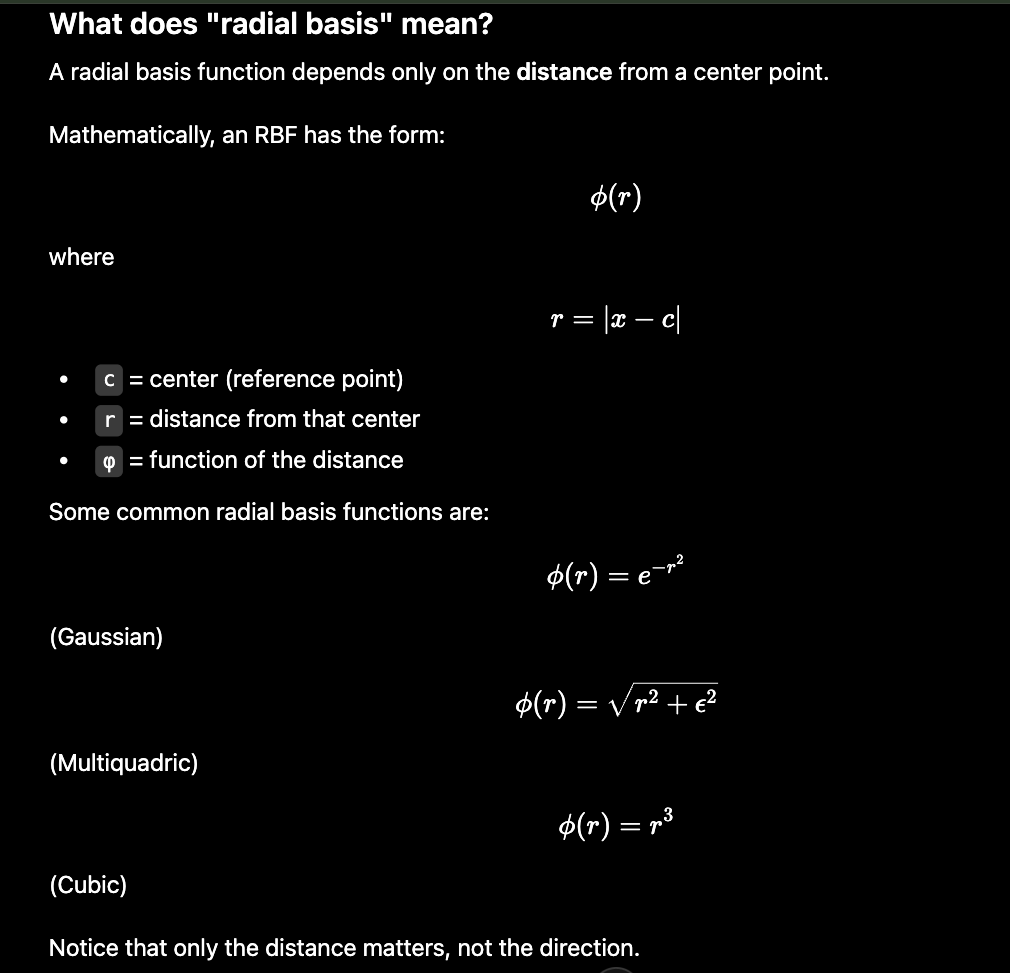

How Rbf() works

Suppose you have data:

xs = [0, 1, 2, 3]
ys = [1, 3, 5, 7]

You create an RBF interpolator:

rbf_func = Rbf(xs, ys)

SciPy places a radial basis function at each x-value:

x=0    x=1    x=2    x=3
 |      |      |      |
 /\     /\     /\     /\
/  \   /  \   /  \   /  \

The final interpolating function is a weighted sum of all these basis functions.

When you evaluate:

rbf_func(2.5)

each basis function contributes according to its distance from 2.5, and the weighted combination produces the interpolated value.

In [34]:
from scipy.interpolate import Rbf
import numpy as np


x=np.arange(10)
y=x**2 + np.sin(x) + 1

rbf_func=Rbf(x,y)

new_x=np.arange(2.1,3.0,0.1)

new_y=rbf_func(new_x)

new_y

array([6.25748981, 6.62190817, 7.00310702, 7.40121814, 7.8161443 ,
       8.24773402, 8.69590519, 9.16070828, 9.64233874])